# Lab 01 — GIS setup and layer visualization

Load the Brussels–Antwerp case study DEM, clutter, and population layers in EPSG:3035.

In [4]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
from broadcast_planner.core.regions import DEFAULT_REGION, EXAMPLES_DIR
from broadcast_planner.core.grids import read_raster, make_grid
from broadcast_planner.data.prepare_examples import generate_example_rasters

if not (EXAMPLES_DIR / 'dem.tif').exists():
    generate_example_rasters(EXAMPLES_DIR)

dem, _ = read_raster(DEFAULT_REGION.dem_path())
clutter, _ = read_raster(DEFAULT_REGION.clutter_path())
population, _ = read_raster(DEFAULT_REGION.population_path())
grid = make_grid(DEFAULT_REGION)
print('Grid', grid.width, 'x', grid.height, '@', grid.resolution_m, 'm')

Grid 400 x 400 @ 250.0 m


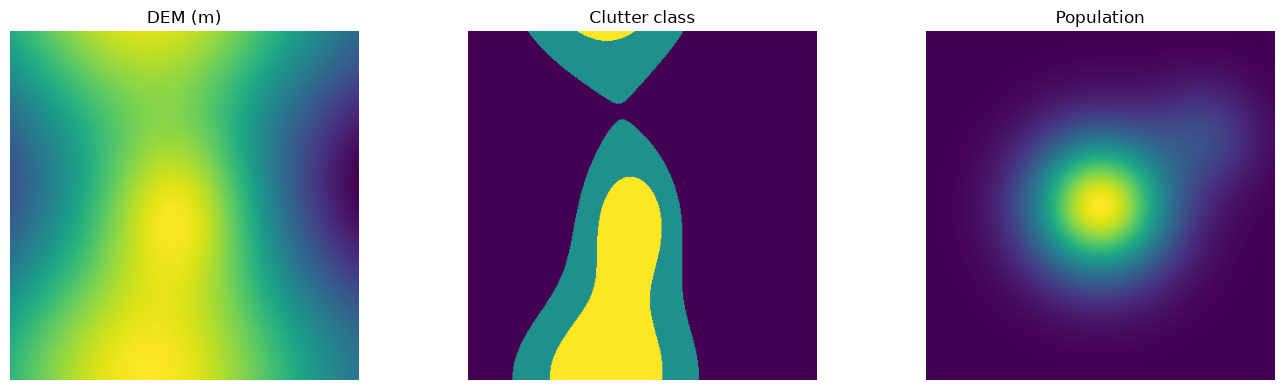

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(dem, origin='upper'); axes[0].set_title('DEM (m)')
axes[1].imshow(clutter, origin='upper'); axes[1].set_title('Clutter class')
axes[2].imshow(population, origin='upper'); axes[2].set_title('Population')
for ax in axes: ax.axis('off')
plt.tight_layout()